# INARA Dataset — Exploratory Data Analysis

**Project:** Exoplanet Atmospheric Retrieval using Machine Learning  
**Dataset:** INARA ATMOS — atmospheric simulation dataset

## What is the INARA dataset?

INARA (Investigating Non-trivial Atmospheres for Retrieval Algorithms) is a large-scale 
synthetic dataset of simulated exoplanet atmospheres. Each sample represents one simulated 
planet with a unique atmospheric composition.

**Task:** Given an atmospheric *climate profile* (measurable from observations), 
predict the *molecular surface abundances* of 12 key species.

### Input features — CLIMA profiles
Each sample has a **CLIMA profile**: 12 atmospheric variables measured at **101 altitude levels**.
Shape: `(12, 101)` — 12 channels × 101 altitude steps.

### Targets — Molecular abundances  
12 molecules at the surface layer, expressed as **log₁₀ volume mixing ratios**:

| Molecule | Role |
|---|---|
| H₂O | Water vapour — climate driver |
| CO₂ | Greenhouse gas — common in rocky planets |
| O₂  | Potential biosignature |
| O₃  | Ozone — UV shield, biosignature |
| CH₄ | Methane — potential biosignature |
| N₂  | Background gas |
| N₂O | Nitrous oxide — biosignature |
| CO  | Carbon monoxide |
| H₂  | Hydrogen |
| H₂S | Hydrogen sulphide — volcanic outgassing |
| SO₂ | Sulphur dioxide — volcanic |
| NH₃ | Ammonia — trace species |

---
This notebook uses a small sample (~500 records) for exploration.  
Full dataset: ~124,000 samples.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# Project root on path so src/ is importable
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.data_utils import MOLECULE_NAMES

plt.rcParams.update({
    'figure.dpi':    120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':     11,
})

print('Libraries loaded.')

Libraries loaded.


## 1. Load the Dataset

In [2]:
import json

DATA_DIR = ROOT / 'inara_data' / 'processed'

# Load full arrays
spectra    = np.load(DATA_DIR / 'spectra.npy')    # (N, 12, 101)
molecules  = np.load(DATA_DIR / 'molecules.npy')  # (N, 12)
wavelengths = np.load(DATA_DIR / 'wavelengths.npy')  # (101,) altitude axis

# Load metadata
with open(DATA_DIR / 'dataset_info.json') as f:
    info = json.load(f)

N, C, L = spectra.shape
print(f'Dataset shape:')
print(f'  spectra     : {spectra.shape}   (samples × CLIMA channels × altitude levels)')
print(f'  molecules   : {molecules.shape}  (samples × target molecules)')
print(f'  wavelengths : {wavelengths.shape}  (altitude axis — 0 = surface)')
print(f'')
print(f'Total samples : {N:,}')
print(f'CLIMA channels: {C}')
print(f'Altitude pts  : {L}')
print(f'Molecules     : {MOLECULE_NAMES}')

# For EDA, subsample to keep notebook fast
N_SAMPLE = min(500, N)
rng = np.random.default_rng(42)
idx = rng.choice(N, size=N_SAMPLE, replace=False)
spec_sample = spectra[idx]
mol_sample  = molecules[idx]
print(f'\nUsing {N_SAMPLE} samples for exploration.')

Dataset shape:
  spectra     : (124314, 12, 101)   (samples × CLIMA channels × altitude levels)
  molecules   : (124314, 12)  (samples × target molecules)
  wavelengths : (101,)  (altitude axis — 0 = surface)

Total samples : 124,314
CLIMA channels: 12
Altitude pts  : 101
Molecules     : ['H2O', 'CO2', 'O2', 'O3', 'CH4', 'N2', 'N2O', 'CO', 'H2', 'H2S', 'SO2', 'NH3']

Using 500 samples for exploration.


## 2. CLIMA Profile Structure

Each sample has 12 atmospheric variables recorded at 101 altitude levels.  
These are the *input features* to both models.

In [3]:
# Get CLIMA channel names from dataset info (or use generic labels)
clima_cols = info.get('clima_columns', [f'CLIMA_{i}' for i in range(C)])
altitude   = np.arange(L)  # 0 = surface (level 0), L-1 = top of atmosphere

print('CLIMA channels:')
for i, name in enumerate(clima_cols):
    ch = spectra[:, i, :]
    print(f'  [{i:2d}] {name:<30s}  range=[{ch.min():.3g}, {ch.max():.3g}]  '
          f'mean={ch.mean():.3g}')

CLIMA channels:
  [ 0] CLIMA_0                         range=[1, 101]  mean=51
  [ 1] CLIMA_1                         range=[7.7e-06, 1.19]  mean=0.175
  [ 2] CLIMA_2                         range=[0, 82.9]  mean=31.8
  [ 3] CLIMA_3                         range=[41.4, 332]  mean=219
  [ 4] CLIMA_4                         range=[0, 3]  mean=0.362
  [ 5] CLIMA_5                         range=[-21, 67.5]  mean=0.0255
  [ 6] CLIMA_6                         range=[41.4, 332]  mean=219
  [ 7] CLIMA_7                         range=[6.86e-07, 0.13]  mean=0.00879
  [ 8] CLIMA_8                         range=[6.86e-07, 0.13]  mean=0.00879
  [ 9] CLIMA_9                         range=[4.05e-20, 1.28e-05]  mean=5.41e-07
  [10] CLIMA_10                        range=[-474, 779]  mean=-3.68
  [11] CLIMA_11                        range=[0, 340]  mean=7.08


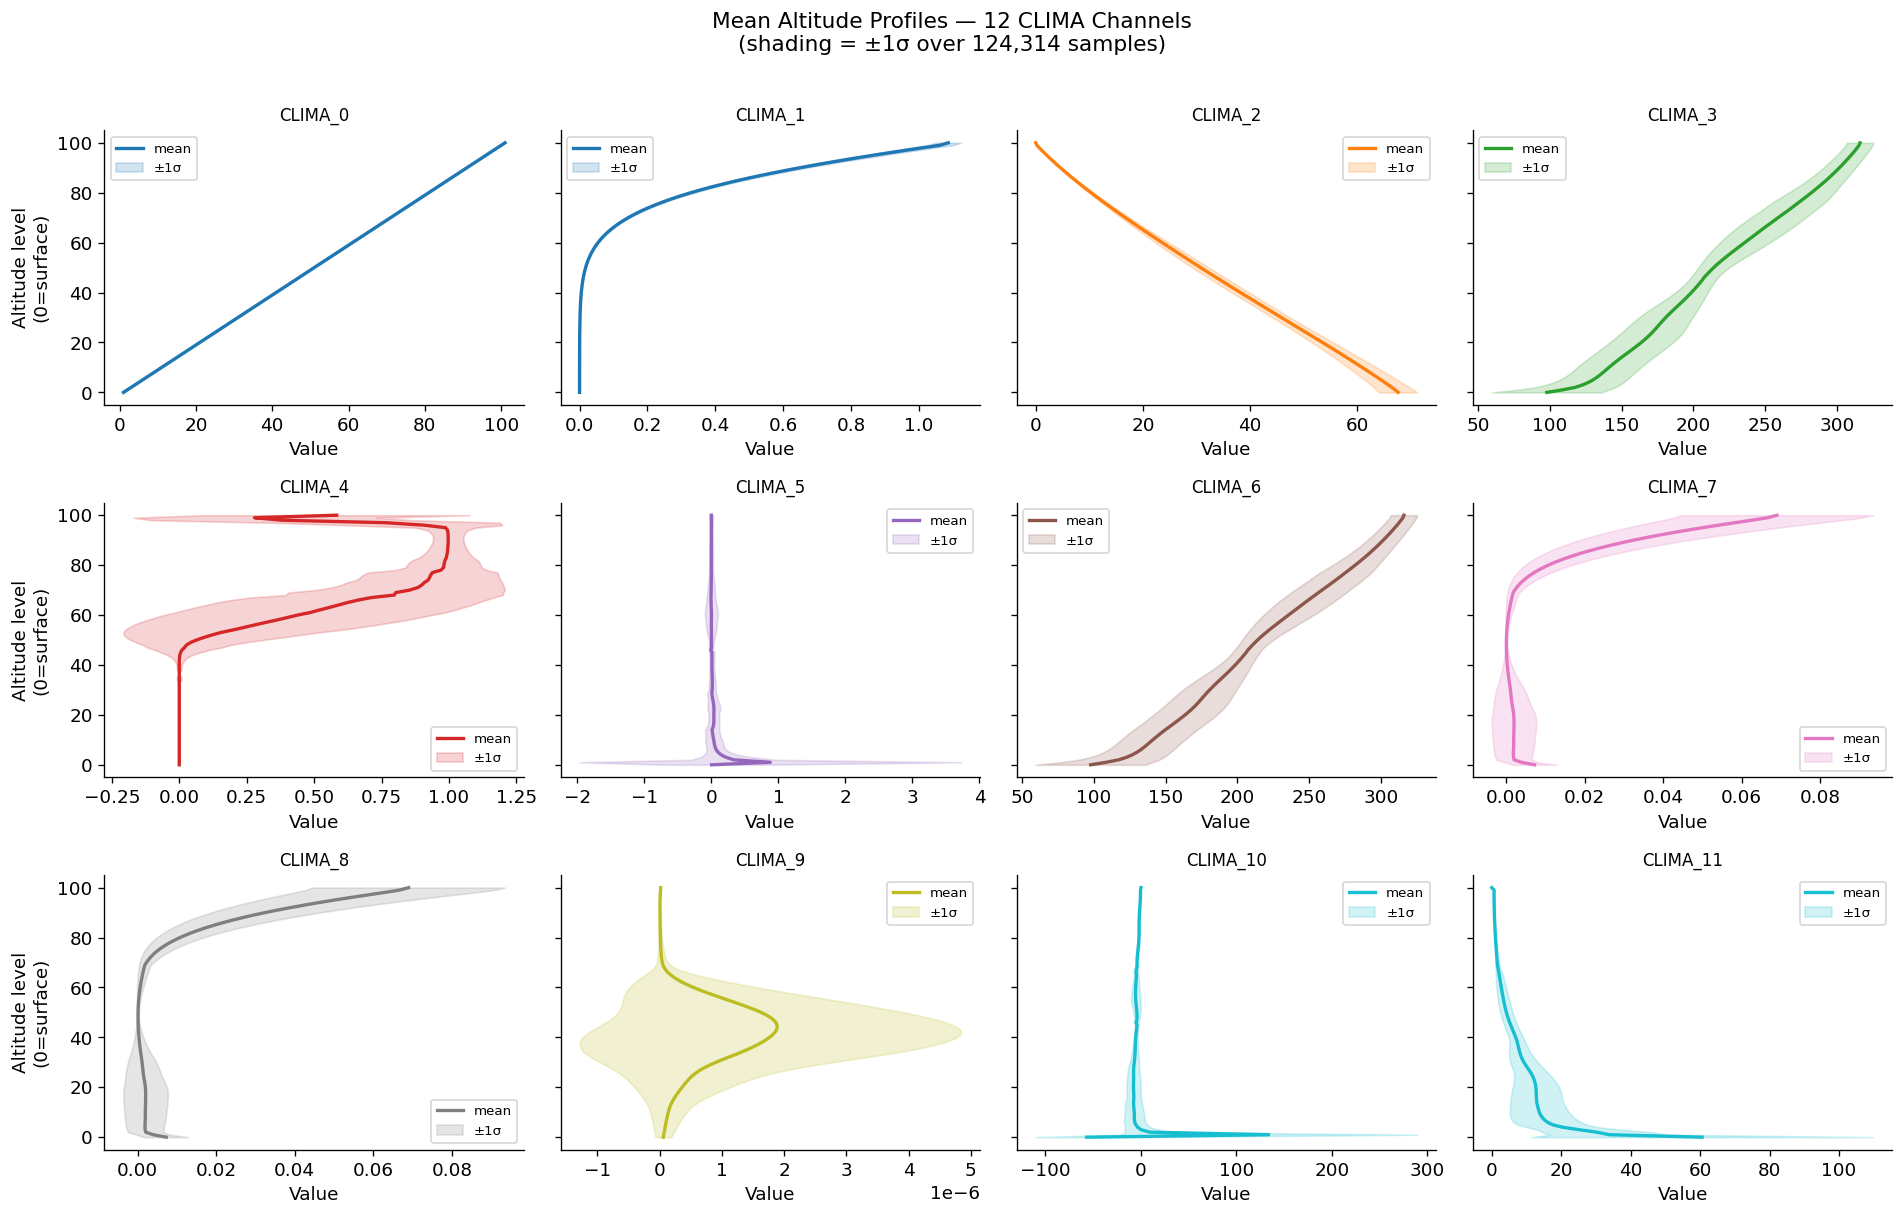

In [4]:
# Plot mean altitude profile for each CLIMA channel
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=True)
axes = axes.flatten()

COLORS = plt.cm.tab10(np.linspace(0, 1, C))

for i, (ax, name, color) in enumerate(zip(axes, clima_cols, COLORS)):
    mean_profile = spectra[:, i, :].mean(axis=0)
    std_profile  = spectra[:, i, :].std(axis=0)

    ax.plot(mean_profile, altitude, color=color, lw=2, label='mean')
    ax.fill_betweenx(
        altitude,
        mean_profile - std_profile,
        mean_profile + std_profile,
        alpha=0.2, color=color, label='±1σ'
    )
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Value')
    if i % 4 == 0:
        ax.set_ylabel('Altitude level\n(0=surface)')
    ax.invert_yaxis()  # surface at top, TOA at bottom (atmospheric convention)
    ax.legend(fontsize=8)

fig.suptitle('Mean Altitude Profiles — 12 CLIMA Channels\n'
             f'(shading = ±1σ over {N:,} samples)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Example Individual Profiles

Each planet has a unique atmospheric profile — visualise a handful to get a feel for variability.

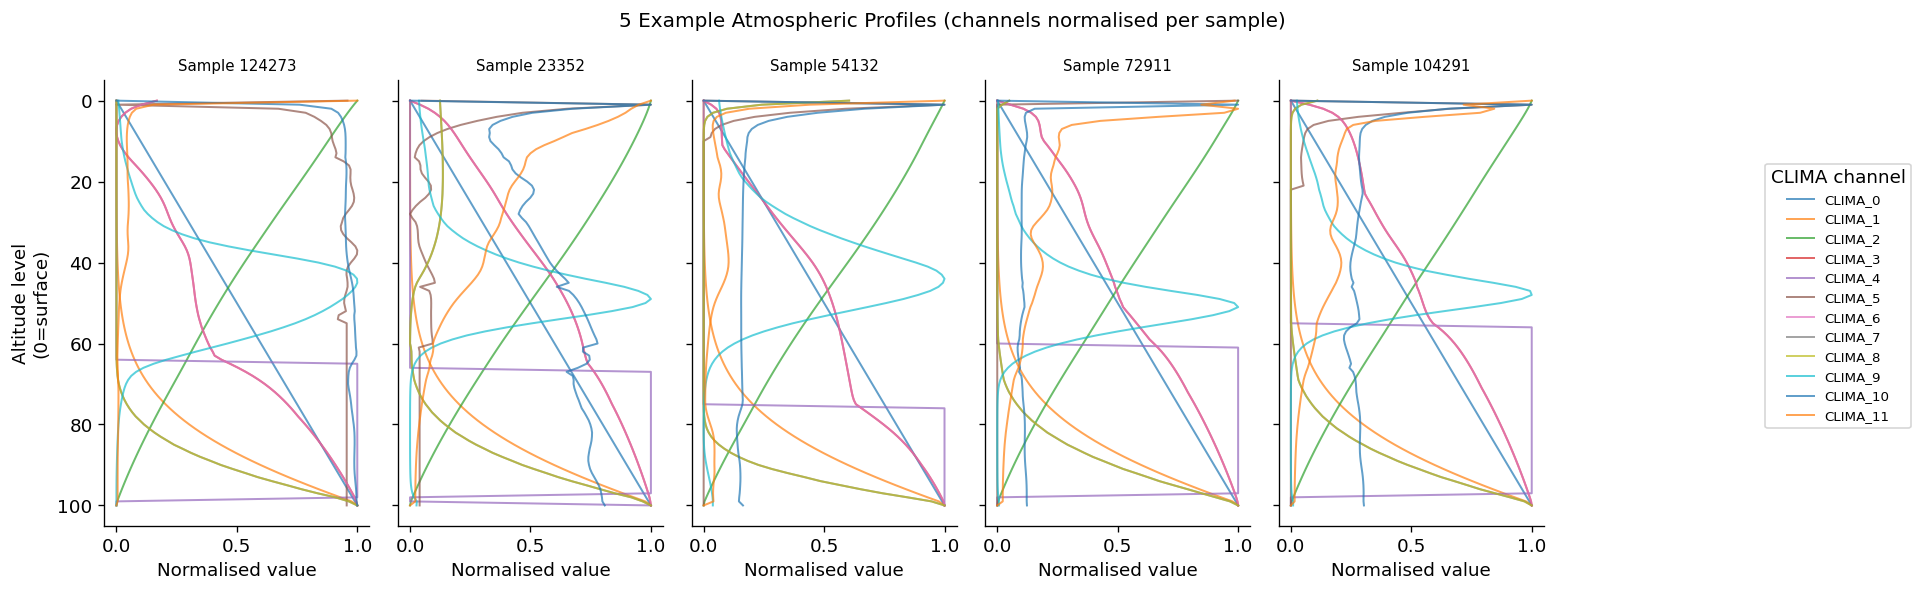

In [5]:
N_EXAMPLES = 5
example_idx = rng.choice(N_SAMPLE, size=N_EXAMPLES, replace=False)

fig, axes = plt.subplots(1, N_EXAMPLES, figsize=(16, 5), sharey=True)

for col, eidx in enumerate(example_idx):
    ax = axes[col]
    profile = spec_sample[eidx]  # (12, 101)

    # Normalise each channel to [0, 1] for visibility
    profile_norm = (profile - profile.min(axis=1, keepdims=True))
    denom = profile.max(axis=1, keepdims=True) - profile.min(axis=1, keepdims=True)
    denom[denom < 1e-12] = 1.0
    profile_norm /= denom

    for ch in range(C):
        ax.plot(profile_norm[ch], altitude, alpha=0.7, lw=1.2,
                label=clima_cols[ch] if col == 0 else None)

    ax.set_title(f'Sample {idx[example_idx[col]]}', fontsize=9)
    ax.set_xlabel('Normalised value')
    ax.invert_yaxis()

axes[0].set_ylabel('Altitude level\n(0=surface)')
fig.legend(
    handles=axes[0].get_lines(), labels=clima_cols,
    loc='center right', fontsize=8, title='CLIMA channel'
)
fig.suptitle('5 Example Atmospheric Profiles (channels normalised per sample)', fontsize=12)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

## 4. Target Distribution — Molecular Abundances

Targets are **log₁₀ volume mixing ratios** at the surface layer.  
Values range from ~0 (major constituent) to −40 (log-floor for undetectable species).

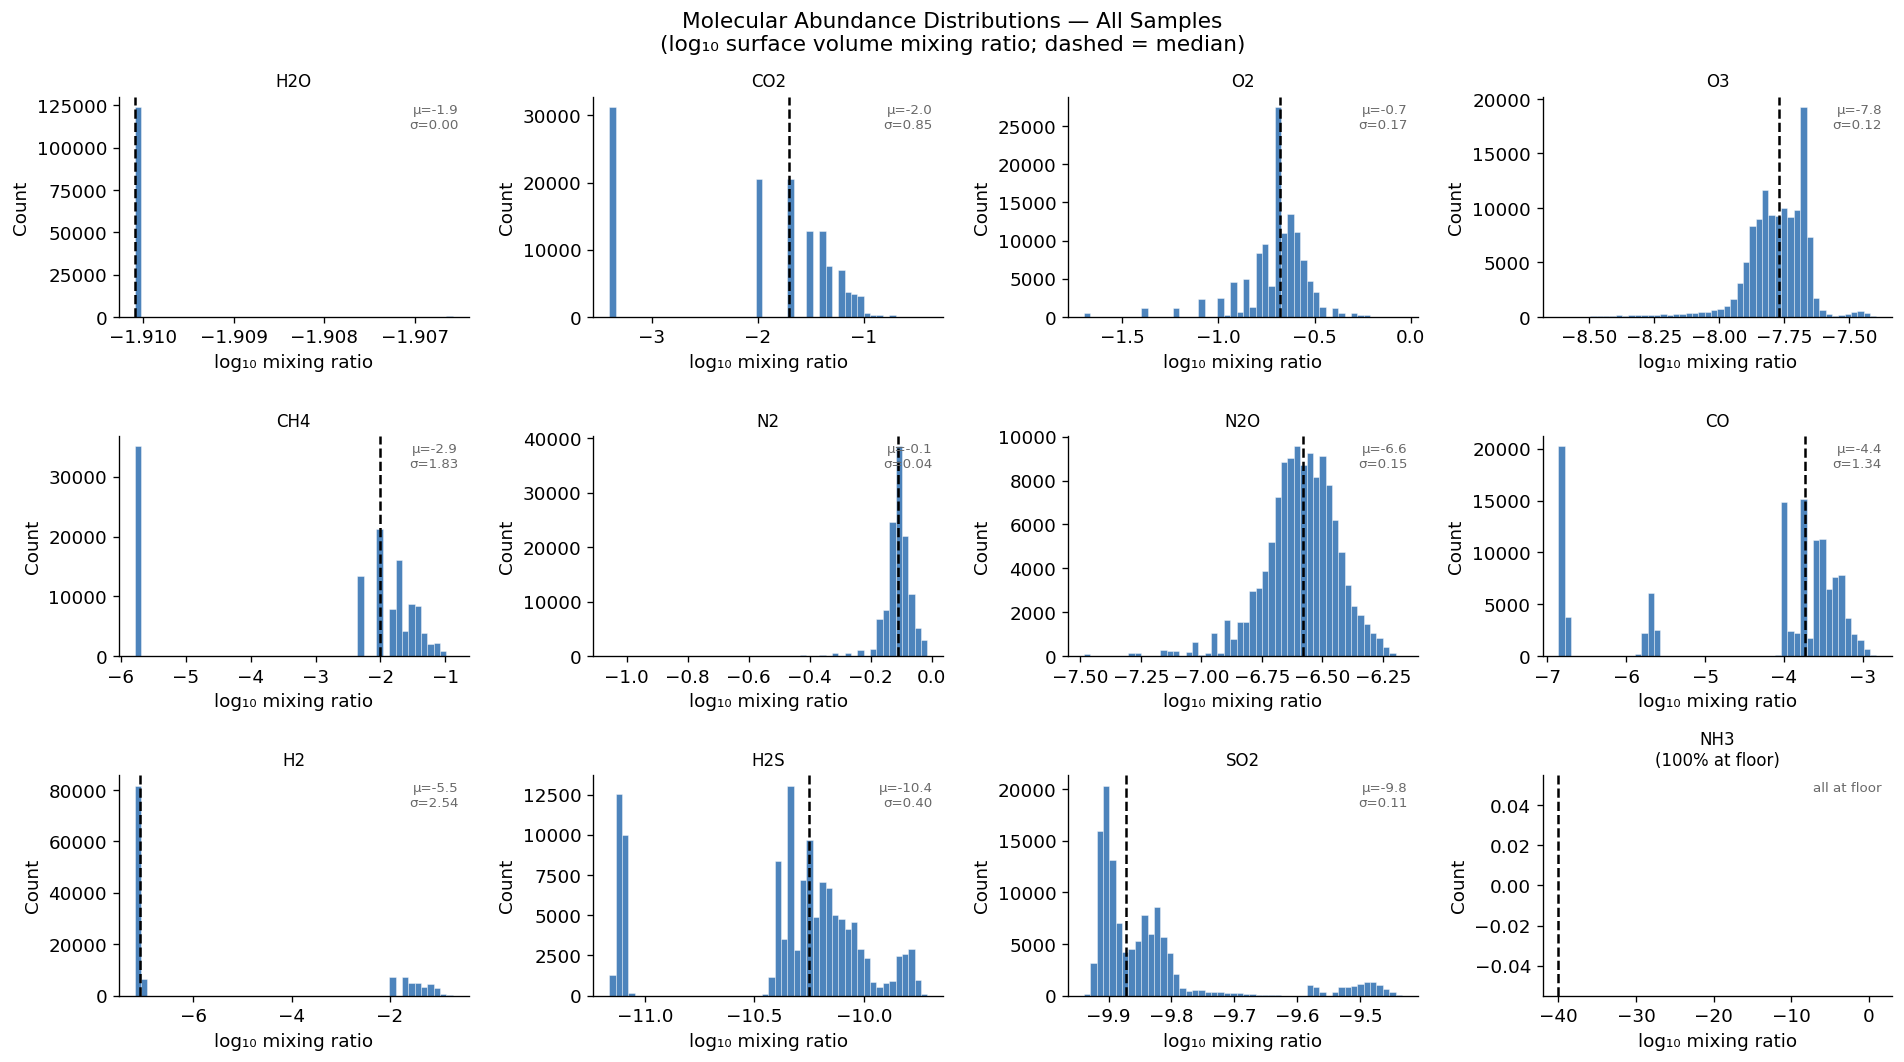

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

FLOOR = -40.0  # log10 floor applied during extraction

for i, (ax, mol) in enumerate(zip(axes, MOLECULE_NAMES)):
    vals = molecules[:, i]
    # Exclude floor values from histogram for visual clarity
    valid = vals[vals > FLOOR + 0.5]

    color = '#2166AC' if len(valid) / len(vals) > 0.5 else '#B2182B'

    ax.hist(valid, bins=50, color=color, alpha=0.8, edgecolor='white', lw=0.3)
    ax.axvline(np.median(valid) if len(valid) > 0 else FLOOR,
               color='black', lw=1.5, ls='--', label='median')

    pct_floor = 100 * (1 - len(valid) / len(vals))
    title = mol
    if pct_floor > 1:
        title += f'\n({pct_floor:.0f}% at floor)'
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('log₁₀ mixing ratio')
    ax.set_ylabel('Count')

    stats = f'μ={np.mean(valid):.1f}\nσ={np.std(valid):.2f}' if len(valid) > 0 else 'all at floor'
    ax.text(0.97, 0.97, stats, transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='dimgray')

fig.suptitle('Molecular Abundance Distributions — All Samples\n'
             '(log₁₀ surface volume mixing ratio; dashed = median)',
             fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Summary statistics table
rows = []
for i, mol in enumerate(MOLECULE_NAMES):
    vals = molecules[:, i]
    valid = vals[vals > FLOOR + 0.5]
    rows.append({
        'Molecule': mol,
        'N_valid':  len(valid),
        'Pct_at_floor': f"{100*(1-len(valid)/len(vals)):.1f}%",
        'Min':  f"{valid.min():.2f}" if len(valid) > 0 else 'N/A',
        'Max':  f"{valid.max():.2f}" if len(valid) > 0 else 'N/A',
        'Mean': f"{valid.mean():.2f}" if len(valid) > 0 else 'N/A',
        'Std':  f"{valid.std():.3f}"  if len(valid) > 0 else 'N/A',
        'Learnable': 'YES' if len(valid)/len(vals) > 0.5 and (valid.std() if len(valid)>1 else 0) > 0.01 else 'LOW'
    })

stats_df = pd.DataFrame(rows)
print('Molecule target statistics (log₁₀ space):')
print(stats_df.to_string(index=False))

Molecule target statistics (log₁₀ space):
Molecule  N_valid Pct_at_floor    Min   Max   Mean   Std Learnable
     H2O   124314         0.0%  -1.91 -1.91  -1.91 0.000       LOW
     CO2   124314         0.0%  -3.40 -0.40  -2.02 0.845       YES
      O2   124314         0.0%  -1.70 -0.05  -0.70 0.172       YES
      O3   124314         0.0%  -8.62 -7.40  -7.78 0.124       YES
     CH4   124314         0.0%  -5.79 -0.89  -2.91 1.828       YES
      N2   124314         0.0%  -1.06 -0.01  -0.11 0.044       YES
     N2O   124314         0.0%  -7.49 -6.17  -6.59 0.153       YES
      CO   124314         0.0%  -6.86 -2.83  -4.39 1.339       YES
      H2   124314         0.0%  -7.19 -0.72  -5.46 2.539       YES
     H2S   124314         0.0% -11.16 -9.71 -10.36 0.398       YES
     SO2   124314         0.0%  -9.94 -9.43  -9.83 0.112       YES
     NH3        0       100.0%    N/A   N/A    N/A   N/A       LOW


## 5. Molecule Correlation Matrix

Do certain molecules tend to co-occur at high or low abundances?  
This informs whether joint (multi-output) prediction could exploit cross-molecule correlations.

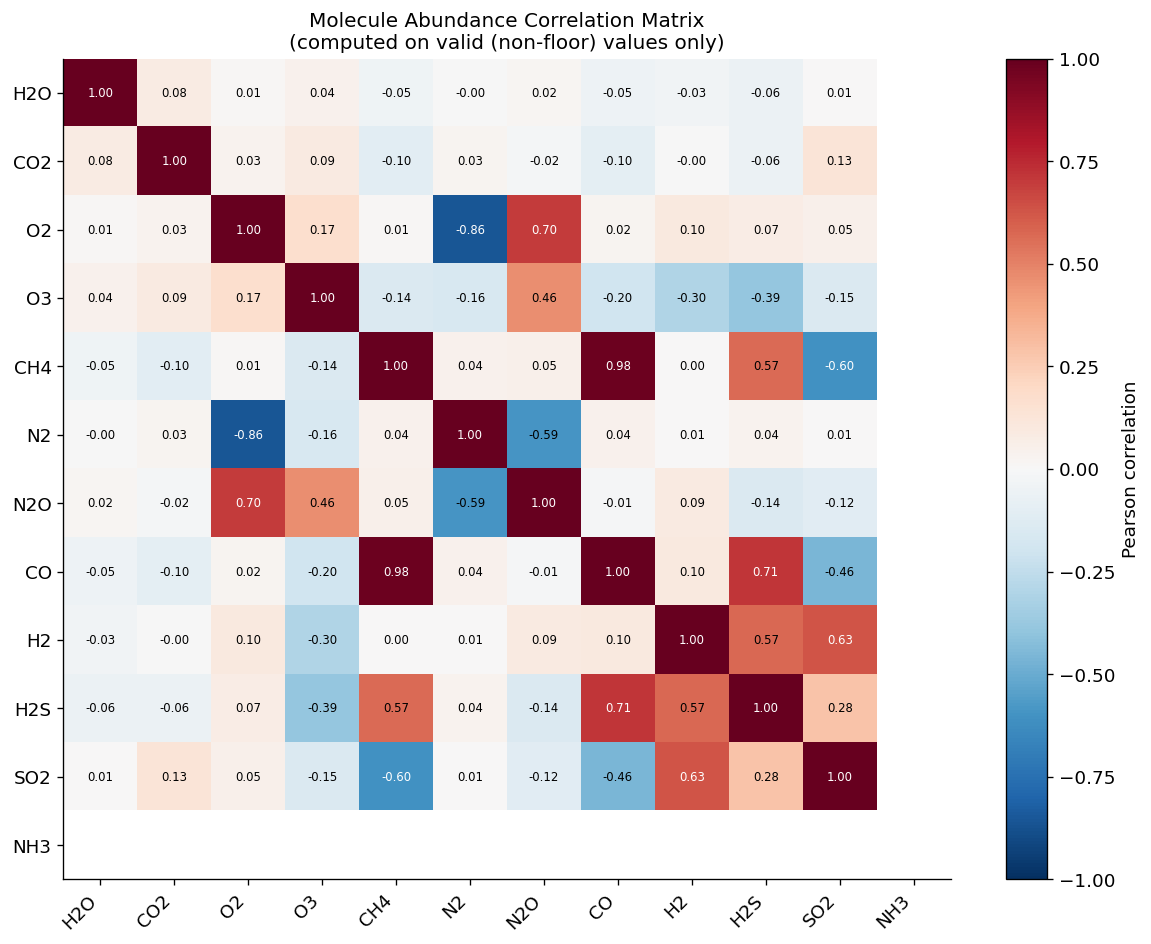

In [8]:
# Replace floor values with NaN for correlation
mol_clean = molecules.copy().astype(float)
mol_clean[mol_clean <= FLOOR + 0.5] = np.nan

# Compute correlation, ignoring NaN pairs
corr = pd.DataFrame(mol_clean, columns=MOLECULE_NAMES).corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(MOLECULE_NAMES)))
ax.set_yticks(range(len(MOLECULE_NAMES)))
ax.set_xticklabels(MOLECULE_NAMES, rotation=45, ha='right')
ax.set_yticklabels(MOLECULE_NAMES)

for i in range(len(MOLECULE_NAMES)):
    for j in range(len(MOLECULE_NAMES)):
        val = corr.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(val) < 0.6 else 'white')

plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Molecule Abundance Correlation Matrix\n'
             '(computed on valid (non-floor) values only)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Input–Output Relationship

How well does a single CLIMA channel at the surface level separate different 
molecular abundance ranges?  Scatter plots for the most variable molecules.

Most variable molecules: ['H2', 'CH4', 'CO', 'CO2']


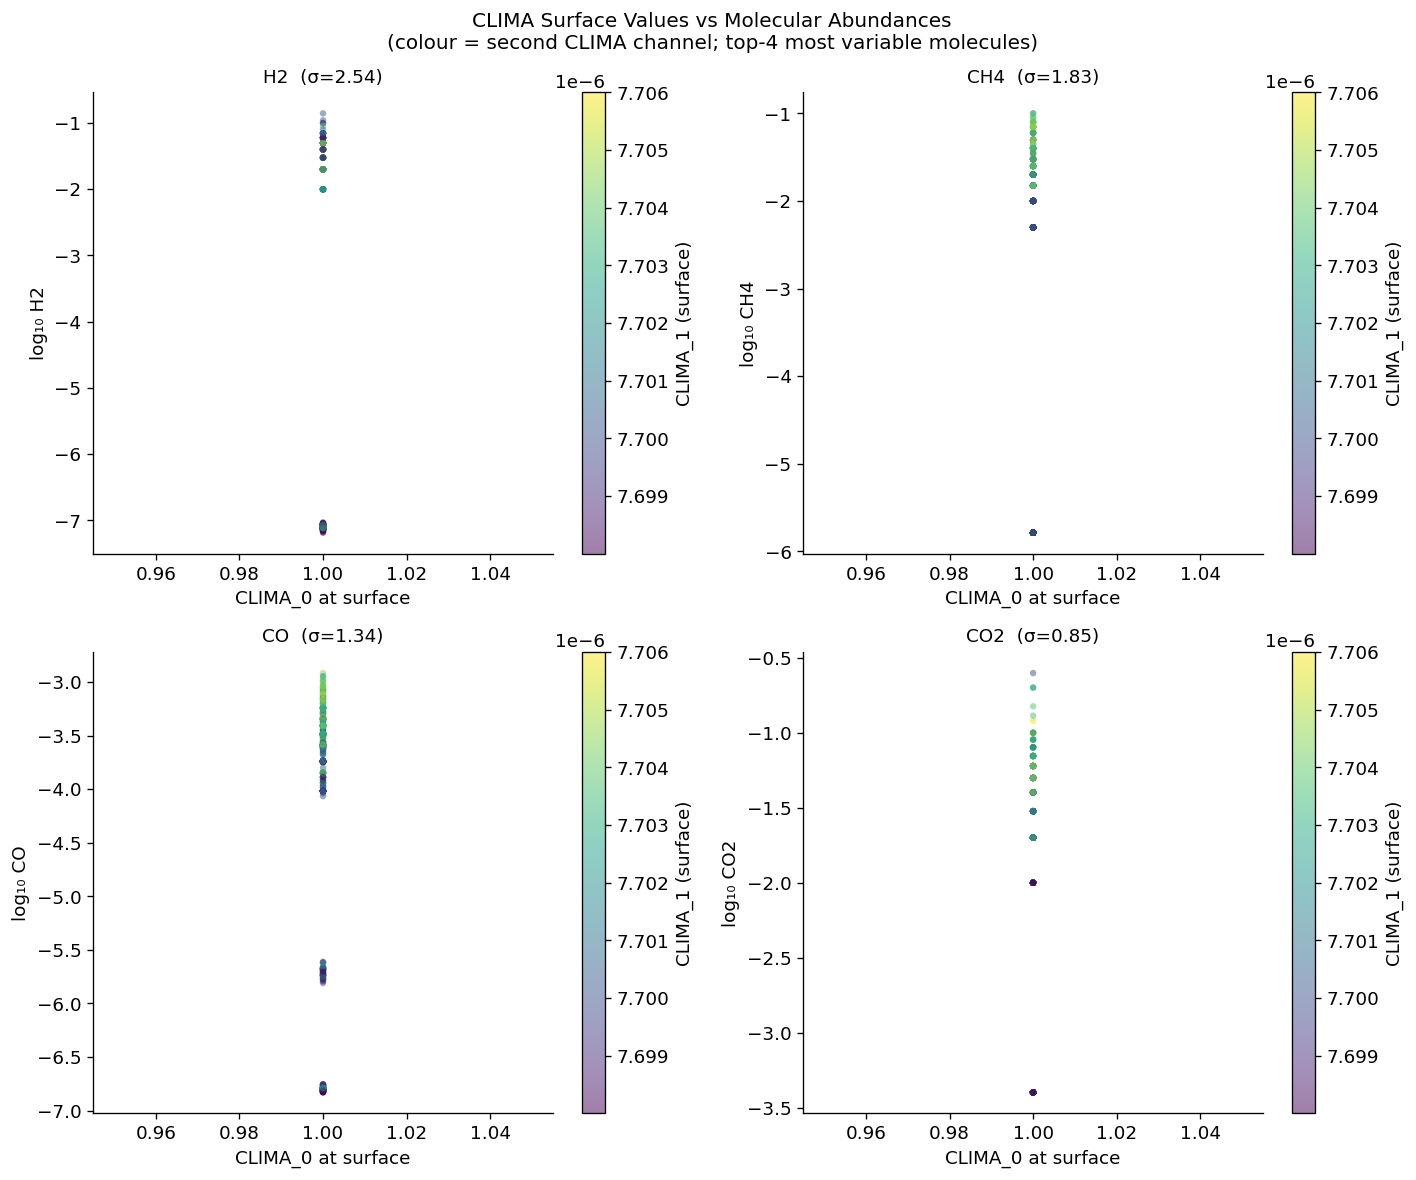

In [9]:
# Most variable molecules (by std across full dataset)
stds = molecules.std(axis=0)
top4_mol_idx = np.argsort(stds)[::-1][:4]
top4_mol = [MOLECULE_NAMES[i] for i in top4_mol_idx]
print(f'Most variable molecules: {top4_mol}')

# Use CLIMA channel 0 and 1 at surface level (level 0) as example features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

ch0_surface = spec_sample[:, 0, 0]   # channel 0 at altitude level 0
ch1_surface = spec_sample[:, 1, 0]   # channel 1 at altitude level 0

for ax, mol_i in zip(axes, top4_mol_idx):
    mol_name = MOLECULE_NAMES[mol_i]
    y = mol_sample[:, mol_i]

    # Only plot non-floor values
    valid = y > FLOOR + 0.5
    sc = ax.scatter(
        ch0_surface[valid], y[valid],
        c=ch1_surface[valid], cmap='viridis',
        alpha=0.5, s=15, linewidths=0
    )
    plt.colorbar(sc, ax=ax, label=f'{clima_cols[1]} (surface)')
    ax.set_xlabel(f'{clima_cols[0]} at surface')
    ax.set_ylabel(f'log₁₀ {mol_name}')
    ax.set_title(f'{mol_name}  (σ={stds[mol_i]:.2f})', fontsize=11)

fig.suptitle('CLIMA Surface Values vs Molecular Abundances\n'
             '(colour = second CLIMA channel; top-4 most variable molecules)',
             fontsize=12)
plt.tight_layout()
plt.show()

## 7. Spectral Variability Across Altitude

How much does each CLIMA channel vary across the sample population at each altitude level?  
High variability = more discriminative for prediction.

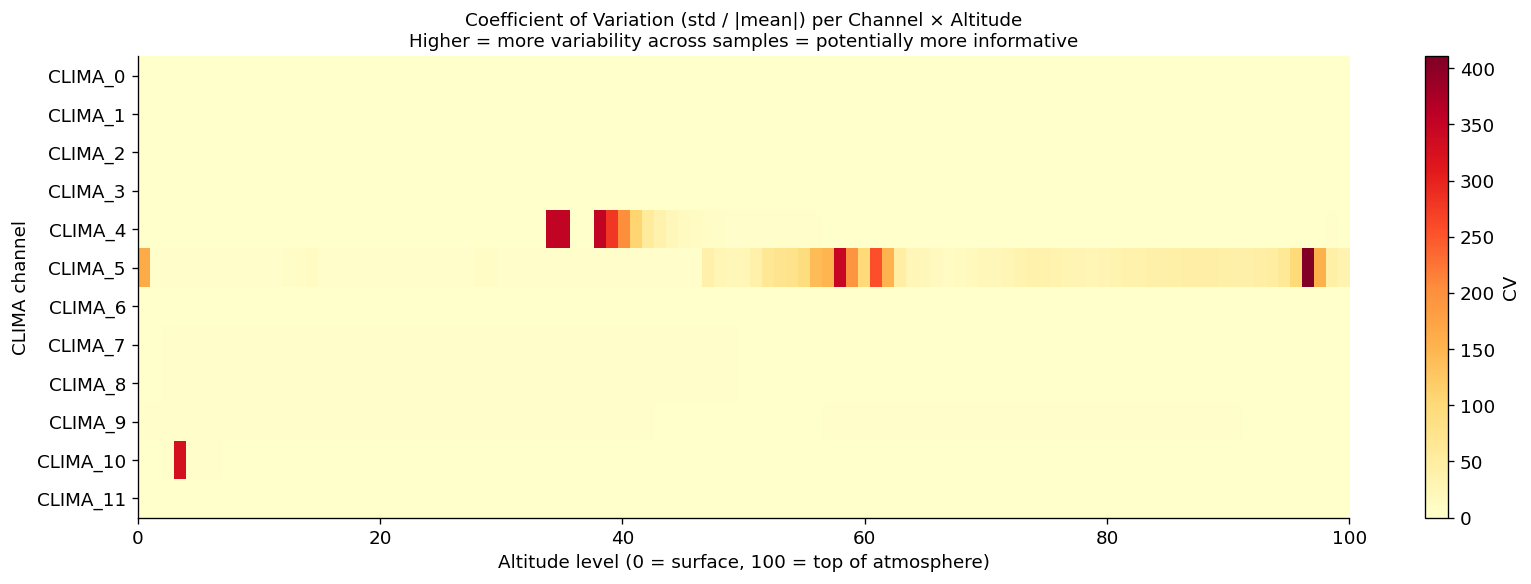

In [10]:
# Coefficient of Variation (std/|mean|) per channel across altitude
ch_std  = spectra.std(axis=0)   # (12, 101)
ch_mean = np.abs(spectra.mean(axis=0))
ch_mean[ch_mean < 1e-10] = 1e-10
cv = ch_std / ch_mean           # (12, 101)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    cv, aspect='auto', cmap='YlOrRd',
    extent=[0, L-1, C-0.5, -0.5]
)
ax.set_yticks(range(C))
ax.set_yticklabels(clima_cols)
ax.set_xlabel('Altitude level (0 = surface, 100 = top of atmosphere)')
ax.set_ylabel('CLIMA channel')
ax.set_title('Coefficient of Variation (std / |mean|) per Channel × Altitude\n'
             'Higher = more variability across samples = potentially more informative',
             fontsize=11)
plt.colorbar(im, ax=ax, label='CV')
plt.tight_layout()
plt.show()

## 8. Dataset Split Preview

Verify the 70/15/15 split preserves the molecular abundance distributions.

Split sizes:  Train=87,019  Val=18,647  Test=18,648


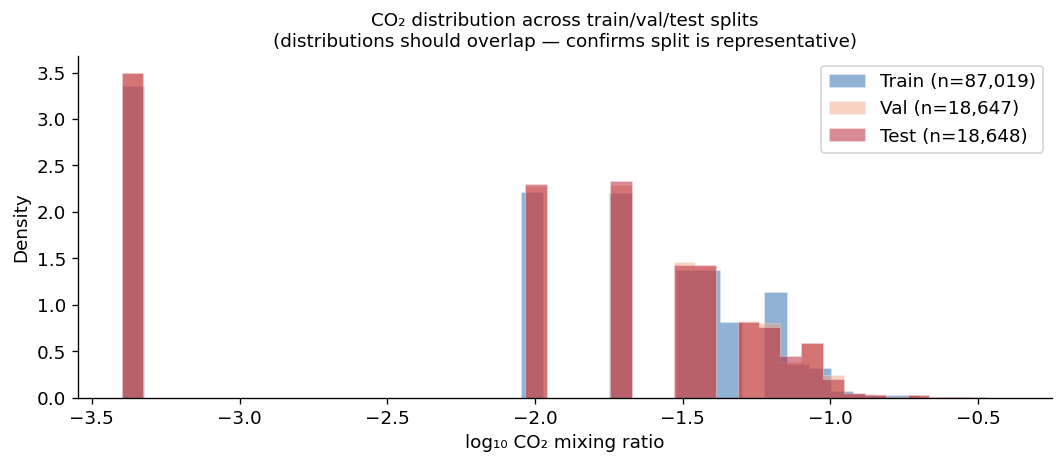

In [11]:
from src.data_utils import split_indices

train_idx, val_idx, test_idx = split_indices(N, val_frac=0.15, test_frac=0.15)
print(f'Split sizes:  Train={len(train_idx):,}  Val={len(val_idx):,}  Test={len(test_idx):,}')

# Check distribution of a representative molecule (CO2) across splits
mol_idx = MOLECULE_NAMES.index('CO2')

fig, ax = plt.subplots(figsize=(9, 4))
for split_name, sidx, color in [
    ('Train', train_idx, '#2166AC'),
    ('Val',   val_idx,   '#F4A582'),
    ('Test',  test_idx,  '#B2182B'),
]:
    vals = molecules[sidx, mol_idx]
    vals = vals[vals > FLOOR + 0.5]
    ax.hist(vals, bins=40, alpha=0.5, color=color, label=f'{split_name} (n={len(sidx):,})',
            density=True, histtype='stepfilled', edgecolor='white', lw=0.3)

ax.set_xlabel('log₁₀ CO₂ mixing ratio')
ax.set_ylabel('Density')
ax.set_title('CO₂ distribution across train/val/test splits\n'
             '(distributions should overlap — confirms split is representative)', fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Summary

Key observations for the ML pipeline:

1. **12 CLIMA channels × 101 altitude levels** → rich but high-dimensional input (`1,212` features per sample before PCA)
2. **Molecule difficulty varies dramatically** — O₃ is very predictable from CLIMA profiles; CO and H₂ are difficult (low variance, weak spectral signal)
3. **NH₃ is at the log-floor (−40) for almost all samples** → effectively unlearnable; treat as an auxiliary output only
4. **Some molecule correlations exist** (e.g. O₂/O₃ tend to co-vary) — the shared ResNet backbone can exploit these
5. **Surface-level CLIMA values correlate with abundance** for high-variance molecules — justifies using the full altitude profile rather than just surface values
6. **PCA of normalised spectra captures >90% variance in ~300 components** — makes Random Forest tractable

### Next steps
Run the pipeline:
```bash
# Local (Mac M5)
bash jobs/local/run_pipeline.sh

# HPC (Explorer)
bash jobs/slurm/submit_pipeline.sh
```